In [6]:
import pandas as pd
from pathlib import Path
from typing import List, Tuple, Set, Optional
import matplotlib.pyplot as plt
import numpy as np

In [2]:
pre_filters_path= Path("/project/imoskowitz/yubin/1-sc_practice/Differential_Gene_Analysis/DataFrames/Pre-pseudobulk-filter")
post_filters_path= Path("/project/imoskowitz/yubin/1-sc_practice/Differential_Gene_Analysis/DataFrames/Post-pseudobulk-filter")
pre_filters = []
for file in sorted(pre_filters_path.iterdir()):
    pre_filters.append(pd.read_csv(file))
    
post_filters = []
for file in sorted(post_filters_path.iterdir()):
    post_filters.append(pd.read_csv(file))


In [3]:
length_pre_filter = []
for filter in pre_filters:
    filter.set_index("Unnamed: 0", inplace=True)
    #display(filter.head())
    length_pre_filter.append(len(filter))


In [4]:
length_post_filter = []
for filter in post_filters:
    filter.set_index("Unnamed: 0", inplace=True)
    #display(filter.head())
    length_post_filter.append(len(filter))

Plot total gene counts

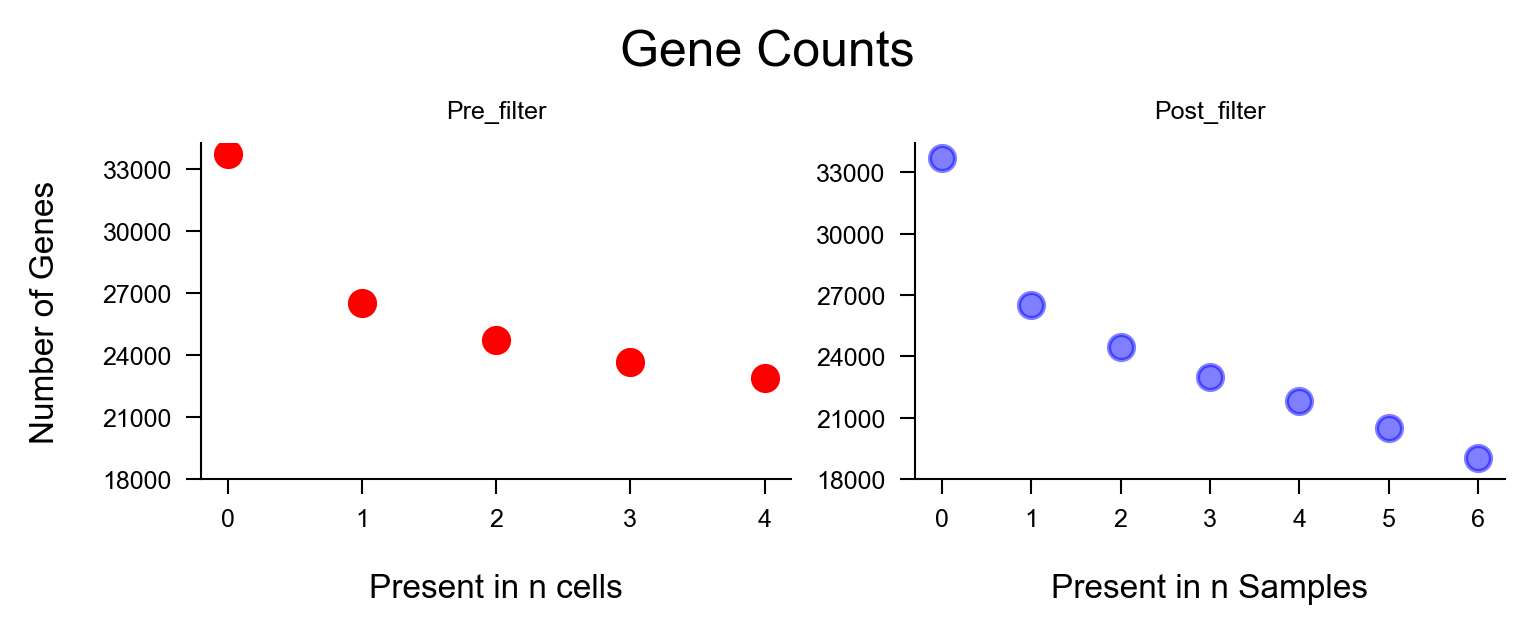

In [16]:
fig, axs = plt.subplots(ncols=2, figsize = (5,2), layout="constrained", dpi = 300)
axs[0].scatter(y = length_pre_filter, x = np.arange(len(length_pre_filter)), color = "red", label = "pre_filter")
axs[0].set_title("Pre_filter")
axs[0].set_xticks(np.arange(len(length_pre_filter)))
axs[0].set_yticks(np.arange(18000,35000,3000))
axs[0].set_xlabel("Present in n cells")
axs[0].set_ylabel("Number of Genes")

axs[1].scatter(y = length_post_filter, x = np.arange(len(length_post_filter)), color = "blue", alpha = 0.5, label = "post_filter")
axs[1].set_title("Post_filter")
axs[1].set_xticks(np.arange(len(length_post_filter)))
axs[1].set_yticks(np.arange(18000,35000,3000))
axs[1].set_xlabel("Present in n Samples")
#axs[1].set_ylabel("Number of Genes")

fig.suptitle("Gene Counts")
fig.savefig("/project/imoskowitz/yubin/1-sc_practice/Differential_Gene_Analysis/Figures/Gene_Count_All.png")

## Making Volcano plot for each filter

In [ ]:
# cd /project/imoskowitz/yubin/SmoNull_NMPs_mesoderm_biased_analysis/src/IV_pseudobulk/

/project/imoskowitz/yubin/SmoNull_NMPs_mesoderm_biased_analysis/src/IV_pseudobulk


In [15]:
# import Katie's code
import sys
sys.path.append("/project/imoskowitz/yubin/SmoNull_NMPs_mesoderm_biased_analysis/src/IV_pseudobulk")
from plot_pseudobulk import custom_volcano_plot

Prefilters

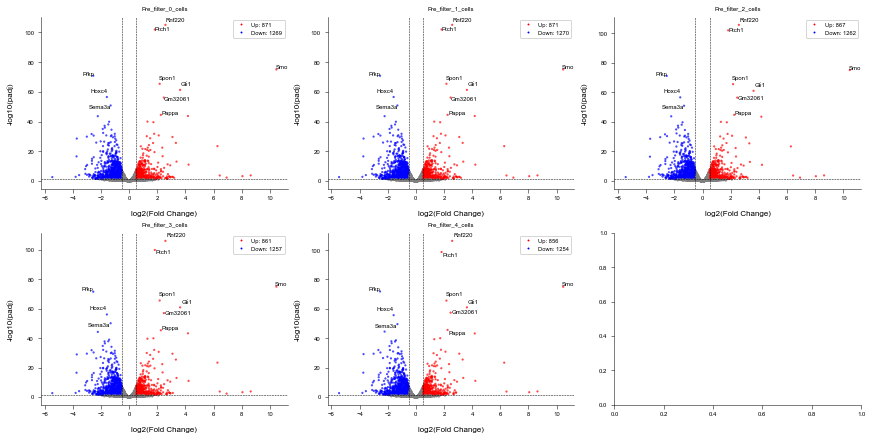

In [17]:
fig, axs = plt.subplots(ncols=3, nrows=2, figsize = (12,6), layout="constrained", dpi = 300)
axs_flat = axs.flatten() 
for i, filter in enumerate(pre_filters):
    custom_volcano_plot(filter, axs_flat[i])
    axs_flat[i].set_title("Pre_filter_" + str(i) + "_cells")

fig.savefig("/project/imoskowitz/yubin/1-sc_practice/Differential_Gene_Analysis/Figures/Volcano_plot_Prefilters.png")

Post filters


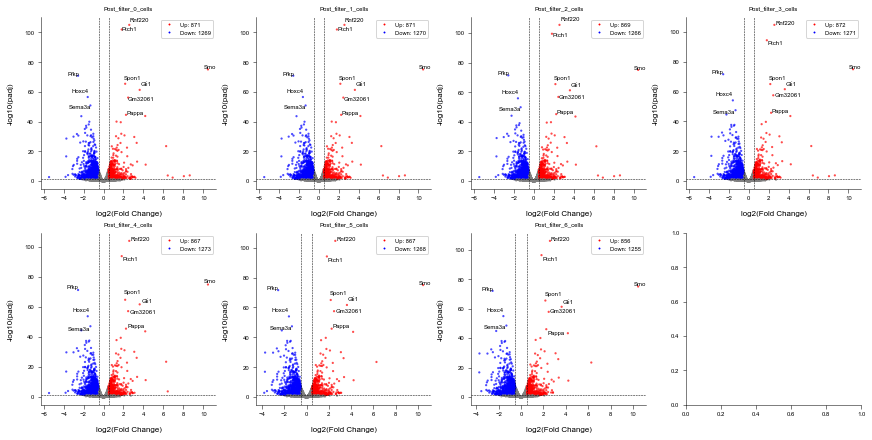

In [18]:
fig, axs = plt.subplots(ncols=4, nrows=2, figsize = (12,6), layout="constrained", dpi = 300)
axs_flat = axs.flatten() 
for i, filter in enumerate(post_filters):
    custom_volcano_plot(filter, axs_flat[i])
    axs_flat[i].set_title("Post_filter_" + str(i) + "_cells")

fig.savefig("/project/imoskowitz/yubin/1-sc_practice/Differential_Gene_Analysis/Figures/Volcano_plot_Postfilters.png")